In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import datasets

In [18]:
class SimpleSMO:
    def __init__(self, C=1.0, tol=1e-3, max_passes=5):
        self.C = C
        self.tol = tol  # 小於此值視為0
        self.max_passes = max_passes
        # self.support_vectors_=np.array([]).reshape(0,2)
        # self.sv_indices_=[]
    # def _kernel(self, x1, x2):
    #     # return x1 @ x2      # 線性核(linear kernel)
    #     return np.dot(x1, x2)   # 線性核(linear kernel)
    def _kernel(self,x):    # 線性核(linear kernel)
        return np.dot(self.X,x.T)
    # def _f(self, x):
    #     return np.sum(self.lambdas * self.y *
    #                   self._kernel(self.X, x)) + self.b
    def _f(self,x):
        return np.dot((self.lambdas * self.y), self._kernel(x))+ self.b        
    def _checkKKT(self,yi,y_hat,lambdai): # 檢查是否符合KKT 條件
        # if (((yi * y_hat-1) < -self.tol and lambdai < self.C) or
        #         ((yi * y_hat-1) >  self.tol and lambdai > 0)):
        #     return False
        # else:
        #     return True

        if ((lambdai<self.tol and yi*y_hat >= 1) or 
            (lambdai>=self.tol and lambdai<self.C and yi*y_hat==1) or
            (lambdai==self.C and yi*y_hat<=1)):
            return True
        else: 
            return False
    def _isMarginPoint(self,yi,y_hat,lambdai):
        return (lambdai>self.tol and lambdai<self.C and yi*y_hat==1)
    def fit(self, X, y):
        m, n = X.shape
        self.X = X
        self.y = y
        self.lambdas = np.zeros(m)   # 初始 lambda 乘子 
        self.b = 0.0                # 初始 偏置         
        K = np.dot(X, X.T)          # 為了計算效率與方便，預先計算線性核矩陣 (X * X.T)
        passes = 0
        sv_indices=set()
        while passes < self.max_passes:
            num_changed = 0            

            for i in range(m):
                # E1 = self._f(X[i]) - y[i]
                E1 = self._f(X[i]) - y[i]

                # 檢查 KKT violation
                # if not self._checkKKT(y[i],self._f(X[i]),self.lambdas[i]): 
                if not self._checkKKT(y[i],self._f(X[i]),self.lambdas[i]): 
                    j = np.random.choice([x for x in range(m) if x != i],replace=False)   # 隨機選第二筆               
                    # if (i==m-1):
                    #     j = np.random.choice([x for x in range(m) if x != i],replace=False)   # 隨機選第二筆
                    # else:
                    #     j=i+1
                    
                    # E2 = self._f(X[j]) - y[j]
                    E2 = self._f(X[j]) - y[j]

                    lambdai_old, lambdaj_old = self.lambdas[i], self.lambdas[j]

                    # 計算 L, H
                    if y[i] != y[j]:
                        L = max(0, lambdaj_old - lambdai_old)
                        H = min(self.C, lambdaj_old - lambdai_old + self.C)
                    else:
                        L = max(0, lambdaj_old + lambdai_old - self.C)
                        H = min(self.C, lambdaj_old + lambdai_old)

                    if L == H:
                        continue

                    # 計算 eta
                    # kii = self._kernel(X[i], X[i])
                    # kjj = self._kernel(X[j], X[j])
                    # kij = self._kernel(X[i], X[j])
                    kii = K[i,i]
                    kjj = K[j,j]
                    kij = K[i,j]
                    eta = kii + kjj - 2 * kij
                    if eta <= 0:
                        continue

                    # 更新 lambda_2
                    self.lambdas[j] += y[j] * (E1 - E2) / eta
                    self.lambdas[j] = np.clip(self.lambdas[j], L, H)    # 依上下限將值裁切

                    if abs(self.lambdas[j] - lambdaj_old) < 1e-5:   # 無更新，跳過
                        continue

                    # 更新 lambda_1
                    self.lambdas[i] += y[i] * y[j] * (lambdaj_old - self.lambdas[j])

                    # update b
                    b1 = (self.b - E1
                          + kii*y[i] * (lambdai_old - self.lambdas[i]) 
                          + kij*y[j] * (lambdaj_old - self.lambdas[j]))

                    b2 = (self.b - E2
                          + kij*y[i] * (lambdai_old - self.lambdas[i]) 
                          + kjj*y[j] * (lambdaj_old - self.lambdas[j]))

                    if 0 < self.lambdas[i] < self.C:
                        self.b = b1
                    elif 0 < self.lambdas[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2)/2

                    num_changed += 1
                else:
                    # if self._isMarginPoint(y[i],self._f(X[i]),self.lambdas[i]):
                    if self._isMarginPoint(y[i],self._f(X[i]),self.lambdas[i]):
                        sv_indices.add(i)
            if num_changed == 0:
                passes += 1
            else:
                passes = 0
        # self.sv_indices_=np.array(list(sv_indices))
        self.sv_indices = np.where(self.lambdas > self.tol)[0] 
    # 輸入值與權重的線性組合
    def decision_function(self,X):
        return np.dot((self.lambdas * self.y), self._kernel(X))+ self.b 
        # return np.dot(X,self.w)+ self.b
    # 使用訓練後的SVM參數進行預測
    def predict(self, X):
        return np.sign(np.array([self._f(x) for x in X]))

In [19]:
iris = datasets.load_iris()
X = iris.data[:, [0, 1]]
y = iris.target
X = X[y != 2]  # 移除第3類 (維吉尼亞鳶尾)
y = y[y != 2]  # 移除第3類的標籤
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.3, random_state=42, stratify=y)
sc = StandardScaler()
X_train_std=sc.fit_transform(X_train)
X_test_std = sc.fit_transform(X_test)
y_train_01=np.where(y_train==0,-1,1)
y_test_01=np.where(y_test==0,-1,1)


In [20]:
ssmo=SimpleSMO(C=1.0,max_passes=10)
ssmo.fit(X=X_train_std,y=y_train_01)
# print("lambdas:", ssmo.lambdas)
print("b:", ssmo.b)
# print("pred:", ssmo.predict(X_train_std))
print(ssmo.predict(X_test_std)==y_test_01)
# print(ssmo.predict(X_train_std)==y_train_01)
print(ssmo.sv_indices)

b: 0.18006780648051607
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True]
[ 6 17 22 26 30 49 52 57 66 69]


In [21]:
# 繪製SVM 的決策邊界和間隔
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 用於正常顯示中文標籤
plt.rcParams['axes.unicode_minus'] = False  # 用於正常顯示負號(若有負數資料)
def plot_decision_boundary(X, y, classifier, sv_indices):    
    # plt.figure(figsize=(10, 8))
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    # 繪製數據點(紅色、藍色區分類別)   
    plt.scatter(X[y == -1, 0], X[y == -1, 1],
                c=colors[0], marker='o', label='Class -1 (Setosa)', alpha=0.6)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], 
                c=colors[1], marker='s', label='Class 1 (Versicolor)', alpha=0.6)
    
    # 標記支持向量(加黑色邊框)
    plt.scatter(X[sv_indices, 0], X[sv_indices, 1],
                s=20, linewidth=2, facecolors='none', 
                edgecolors='black',label='Support Vectors')
    
    # 繪製決策邊界
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),    #   xx.shape=(200,200) yy.shape=(200,200)
                         np.linspace(y_min, y_max, 200))
    
    # 計算網格點的決策函數值
    Z = classifier.predict(np.array([xx.ravel(), yy.ravel()]).T)    # 為每一個配對的點計算預測值
    Z = Z.reshape(xx.shape)
    Z1= classifier.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z1 = Z1.reshape(xx.shape)
    # 繪製決策邊界和間隔
    plt.contour(xx, yy, Z1, levels=[-1, 0, 1],   # 只畫等高線[-1, 0, 1]
                cmap=cmap,
                # colors=['blue', 'black', 'red'], 
                linestyles=['--', '-', '--'], 
                linewidths=[1, 2, 1])    
    plt.contourf(xx, yy, Z,
                 cmap=cmap, 
                #  colors=['lightblue', 'lightcoral'], 
                 alpha=0.3)
    
    plt.xlabel('萼片長 (已標準化)')
    plt.ylabel('萼片寬 (已標準化)')
    plt.title('SVM 決策邊界最大化')
    plt.legend()
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.grid(True, alpha=0.3)
    plt.show()

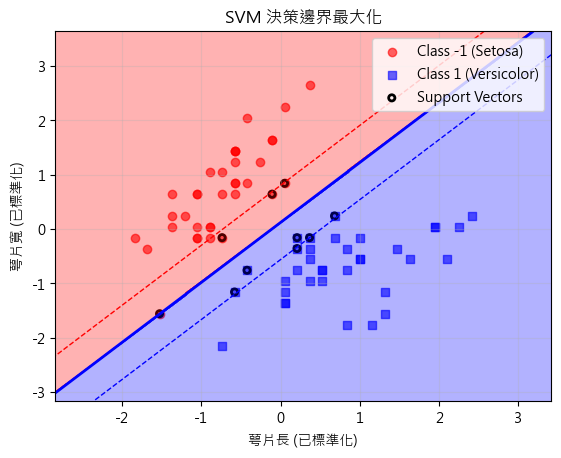

In [22]:
plot_decision_boundary(X_train_std, y_train_01,ssmo, ssmo.sv_indices)